In [1]:
import os
from IPython.display import Image, display, HTML
import pandas as pd
import matplotlib.pyplot as plt
import boto3
import pickle
from pprint import pprint
import json
import numpy as np
import pandas as pd
import time
from PIL import Image as img
import seaborn as sns

try:
    import catboost
except ModuleNotFoundError:
    ! pip install catboost==1.0.4

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.0' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Functions

In [2]:
# download from s3
def download_from_s3(str_local_path, str_bucket_path, str_project):
    # download file
    boto3.client('s3').download_file(str_project, str_bucket_path, str_local_path)

In [3]:
# show transformers
def show_transformers(list_transformers):
    # iterate
    for a, transformer in enumerate(list_transformers):
        print(f'{a+1}: {transformer.__class__.__name__} - {transformer.str_message}')

## Constants

In [4]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
str_model = os.getcwd().split('/')[5]
print(f'Model: {str_model}')
str_variant = os.getcwd().split('/')[8][3:]
print(f'Variant: {str_variant}')
str_dirname_output = './output'

Project: 20231010-gen-xii
Model: 02_pricing_pd
Variant: model4


## Make output directory

In [5]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

## Data prep

### EDA - part 1

In [6]:
str_filename = 'dict_df_info.json'
str_local_path = f'../../../01_data_prep/02_eda_pt_1/output/{str_filename}'
dict_df_info = json.load(open(str_local_path, 'r'))
df_info = pd.DataFrame(dict_df_info, index=[0])
df_info.columns = ['Rows','Columns','Total Obs.','Min. Date','Max. Date','Target Mean','Prop. NaN']
df_info['Data Set'] = 'All'
df_info = df_info[['Data Set','Rows','Columns','Total Obs.','Min. Date','Max. Date','Prop. NaN','Target Mean']]
df_info

,Data Set,Rows,Columns,Total Obs.,Min. Date,Max. Date,Prop. NaN,Target Mean
0,All,124316,2490,309546840,2013-10-01 07:28:54.833000,2017-10-28 11:35:40.970000,0.23473,0.344984


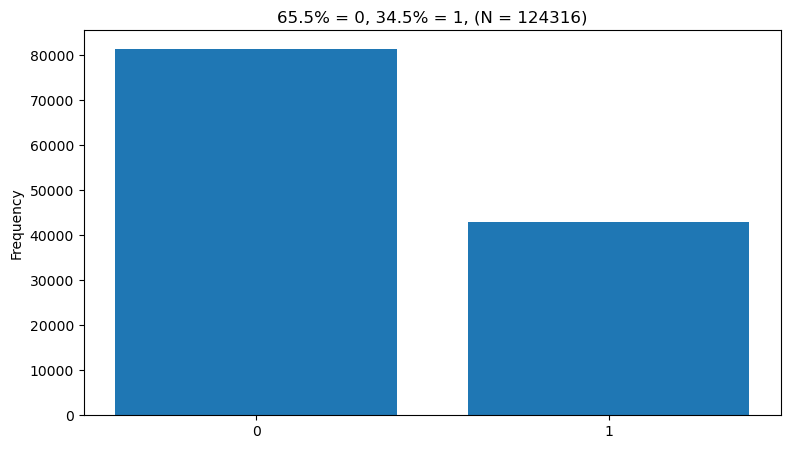

In [7]:
# download
str_filename = 'plt_target.png'
str_local_path = f'../../../01_data_prep/02_eda_pt_1/output/{str_filename}'

# show
Image(filename=str_local_path)

### EDA - part 2

In [8]:
str_filename = 'df_info_summary.csv'
str_local_path = f'../../../01_data_prep/04_eda_pt_2/output/{str_filename}'
df = pd.read_csv(str_local_path)
df

,Data Set,Rows,Columns,Total Obs.,Min. Date,Max. Date,Prop. NaN,Target Mean
0,Train,74589,2490,185726610,2013-10-01 07:28:54.833000,2016-03-17 16:21:03.933000,0.255077,0.353309
1,Valid,24863,2490,61908870,2016-03-17 16:21:40.237000,2016-11-18 17:12:48.527000,0.248822,0.373125
2,Test,24864,2490,61911360,2016-11-18 17:12:48.527000,2017-10-28 11:35:40.970000,0.159601,0.291868


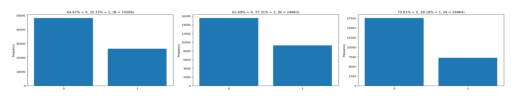

In [9]:
# paths
str_local_path_1 = '../../../01_data_prep/04_eda_pt_2/output/plt_target_train.png'
str_local_path_2 = '../../../01_data_prep/04_eda_pt_2/output/plt_target_valid.png'
str_local_path_3 = '../../../01_data_prep/04_eda_pt_2/output/plt_target_test.png'

# open images
image1 = img.open(str_local_path_1)
image2 = img.open(str_local_path_2)
image3 = img.open(str_local_path_3)

# get the original width
int_width_original = image1.width
# get the height
int_height_original = image1.height
# get the ratio
int_ratio = round(int_width_original / int_height_original)

# set new width
int_width_new = 1000
# calculate new height
int_height_new = round(int_width_new / int_ratio)

# resize
tpl_size = (int_width_new, int_height_new)
image1 = image1.resize(tpl_size)
image2 = image2.resize(tpl_size)
image3 = image3.resize(tpl_size)

# Combine the images side by side
int_width_new_combined = int_width_new * 3
tpl_size = (int_width_new_combined, int_height_new)
combined_image = img.new(
    mode='RGB', 
    size=tpl_size,
)
combined_image.paste(image1, (0, 0))
combined_image.paste(image2, (int_width_new, 0))
combined_image.paste(image3, (int_width_new * 2, 0))

# Display the combined image in the Jupyter Notebook
plt.imshow(combined_image)
plt.axis('off')
plt.show()

### Leaky features

In [10]:
# show leaky features
str_filename = 'df_cols_bad.csv'
str_local_path = f'../../../01_data_prep/05_leaky_features/03_leaky/output/{str_filename}'
df = pd.read_csv(str_local_path)
print(f'There are {df.shape[0]} leaky features:')
# show
df

There are 879 leaky features:


,feature,from_nan,from_df,from_name,sum
0,dtmstampcreation__base,1,1,1,3
1,score_bankcard__tu,1,1,1,3
2,dtmapproved__base,1,1,1,3
3,score_cvpropensity__tu,1,1,1,3
4,middlename__tu,1,1,1,3
...,...,...,...,...,...
874,dtmapproved__app,0,0,1,1
875,approvaldate__app,0,0,1,1
876,credit_as_of_date__tu,0,0,1,1
877,ssndatelowissued__ln,0,0,1,1


### EDA - part 3

In [11]:
str_filename = 'df_info_summary.csv'
str_local_path = f'../../../01_data_prep/06_eda_pt_3/output/{str_filename}'
df = pd.read_csv(str_local_path)
df

,Data Set,Rows,Columns,Total Obs.,Min. Date,Max. Date,Prop. NaN,Target Mean
0,Train,74589,1613,120312057,2013-10-01 07:28:54.833000,2016-03-17 16:21:03.933000,0.086232,0.353309
1,Valid,24863,1613,40104019,2016-03-17 16:21:40.237000,2016-11-18 17:12:48.527000,0.076505,0.373125
2,Test,24864,1613,40105632,2016-11-18 17:12:48.527000,2017-10-28 11:35:40.970000,0.084543,0.291868


## Preprocessing

### Step function schematic

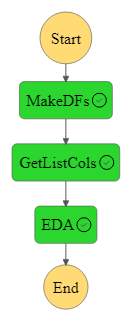

In [12]:
# download
str_filename = 'schematic.png'
str_local_path = f'../../00_preprocessing/05_step_function/img/{str_filename}'

# show
Image(filename=str_local_path)

### Preprocessing model

In [13]:
try:
    str_filename = f'preprocessing.py'
    str_local_path = f'./{str_filename}'
    str_bucket_path = f'01_ad/02_model/{str_variant}/00_preprocessing/01_create_preprocessor/{str_filename}'
    download_from_s3(
        str_local_path=str_local_path, 
        str_bucket_path=str_bucket_path, 
        str_project=str_project,
    )
    str_filename = f'cls_model_preprocessing.pkl'
    str_local_path = f'./{str_filename}'
    str_bucket_path = f'01_ad/02_model/{str_variant}/00_preprocessing/01_create_preprocessor/{str_filename}'
    download_from_s3(
        str_local_path=str_local_path, 
        str_bucket_path=str_bucket_path, 
        str_project=str_project,
    )
    # show pipeline
    list_transformers = pickle.load(open(str_local_path, 'rb')).list_transformers
    print('Preprocessing model steps:')
    show_transformers(list_transformers)

    # rm
    for str_file in [f'preprocessing.py', f'cls_model_preprocessing.pkl']:
        os.remove(str_file)
except:
    pass

Preprocessing model steps:
1: ReplaceNaNs - NaN Replacer
2: ReplaceBooleans - Boolean Replacer
3: SetDataTypes - Data Type Setter
4: CleanText - Clean text and impute non-numeric
5: Inflator - Inflate to 2022 dollars
6: ClipValues - Clip negative dollar values to zero (automobile and non-automobile)
7: ClipValues - Clip number of income sources to 2
8: CustomImputer - Custom imputer
9: Imputer - Imputer
10: FeatureValueReplacer - Replace zeros with predetermined value
11: DateFeatures - Date features
12: RoundBinning - Round income (for PTI), amount financed and vehicle values for (LTV)
13: FeatureEngineering - Feature engineering
14: ReplaceInf - Replace inf and -inf with NaN
15: Imputer - Imputer
16: MapTerm - Map term
17: MapPTI - Map PTI
18: RoundBinning - Round values


In [14]:
# get the number of engineered features
str_filename = 'df_list_features.csv'
str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/01_feat_select/01_lambda_get_starting_feats/{str_filename}'
list_cols = list(pd.read_csv(str_uri)['feature'])
list_cols = [col for col in list_cols if 'ENG-' in col]
print(f'There are {len(list_cols)} engineered features available in the model:')
pprint(list_cols)

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/fsspec/registry.py:272: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


There are 5 engineered features available in the model:
['ENG-applicationdate__app_month',
 'ENG-applicationdate__app_quarter',
 'ENG-loan_to_value',
 'ENG-vehicle_age',
 'ENG-dealership_age']


In [15]:
str_filename = 'df_info_summary.csv'
str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/00_preprocessing/04_eda/{str_filename}'
df = pd.read_csv(str_uri)
df

,Data Set,Rows,Columns,Total Obs.,Min. Date,Max. Date,Prop. NaN,Target Mean
0,Train,74589,1620,120834180,2013-10-01 07:28:54.833000,2016-03-17 16:21:03.933000,0.000636,0.353309
1,Valid,24863,1620,40278060,2016-03-17 16:21:40.237000,2016-11-18 17:12:48.527000,0.000630,0.373125
2,Test,24864,1620,40279680,2016-11-18 17:12:48.527000,2017-10-28 11:35:40.970000,0.000653,0.291868


## Feature selection

### Step function schematic

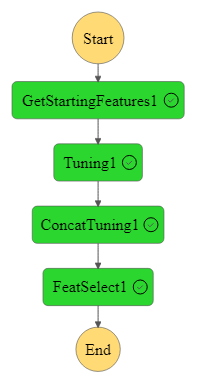

In [16]:
# download
str_filename = 'schematic.png'
str_local_path = f'../../01_feat_select/05_step_function/img/{str_filename}'

# show
Image(filename=str_local_path)

### Hyperparameters for step function

In [17]:
str_filename = 'df_hyperparameters.csv'
str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/01_feat_select/05_step_function/{str_filename}'
df = pd.read_csv(str_uri)
# show
df

,keys,values
0,STR_FILENAME_TRAIN,df_train_noleaks_pre.gzip
1,STR_FILENAME_VALID,df_valid_noleaks_pre.gzip
2,INT_N_ITERATIONS,1000
3,PROP_EARLY_STOPPING,0.1
4,INT_N_TUNING_JOBS_1,100
5,STR_EVAL_METRIC,AUC


### Starting features

In [18]:
str_filename = 'df_list_features.csv'
str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/01_feat_select/01_lambda_get_starting_feats/{str_filename}'
df = pd.read_csv(str_uri)
print(f'There were {df.shape[0]} features eligible for the model')

There were 1536 features eligible for the model


### Tuning

In [19]:
str_filename = 'df_tuning.csv'
str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/01_feat_select/03_lambda_concat_tuning/{str_filename}'
df = pd.read_csv(str_uri)
# show
df

,iteration,learning_rate,flt_eval_metric_train,flt_eval_metric_valid,diff,best_iteration
0,5,0.0514,0.879020,0.745963,0.133057,746
1,7,0.0716,0.881599,0.745817,0.135782,560
2,11,0.1119,0.882121,0.745764,0.136357,395
3,4,0.0413,0.871968,0.745618,0.126350,840
4,9,0.0917,0.866841,0.745583,0.121257,367
...,...,...,...,...,...,...
95,86,0.8679,0.782631,0.723411,0.059220,17
96,93,0.9385,0.775521,0.723219,0.052302,14
97,91,0.9184,0.788446,0.722992,0.065454,19
98,99,0.9990,0.785192,0.721025,0.064166,17


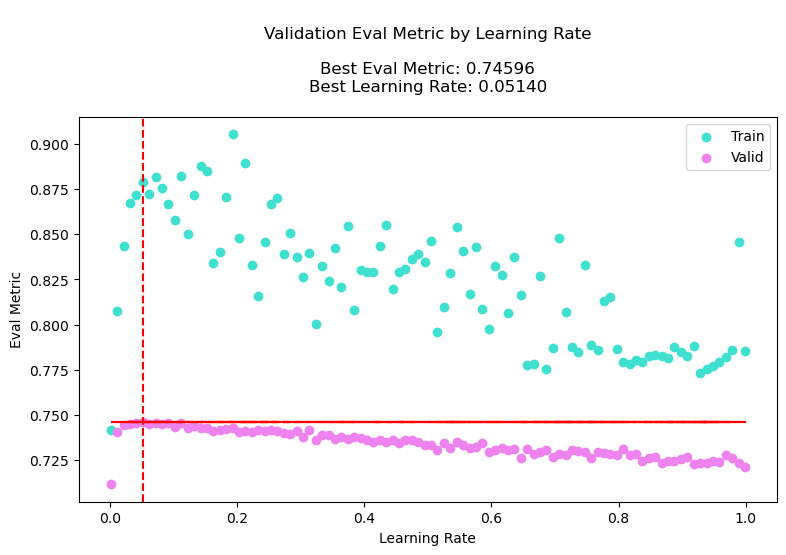

In [20]:
# plot
fig, ax = plt.subplots(figsize=(9,5))
flt_best_lr = df['learning_rate'].iloc[0]
flt_best_metric = df['flt_eval_metric_valid'].iloc[0]
str_title = f"""
Validation Eval Metric by Learning Rate

Best Eval Metric: {flt_best_metric:0.5f}
Best Learning Rate: {flt_best_lr:0.5f}
"""
ax.set_title(str_title)
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Eval Metric')
ax.scatter(df['learning_rate'], df['flt_eval_metric_train'], label='Train', color='turquoise')
ax.scatter(df['learning_rate'], df['flt_eval_metric_valid'], label='Valid', color='violet')
ax.axvline(x=flt_best_lr, linestyle='--', color='red')
ax.plot(df['learning_rate'], [flt_best_metric for a in range(df.shape[0])], linestyle='--', color='red')
plt.legend()
# save and show
plt.savefig(f'{str_dirname_output}/plt_tuning_1.png', bbox_inches='tight')
plt.show()

In [21]:
# get the model with the best validation metric to visualize overfitting
bool_ascending = False
df_tmp = df.sort_values(by='flt_eval_metric_valid', ascending=bool_ascending, inplace=False)
flt_eval_metric_train_0 = df_tmp['flt_eval_metric_train'].iloc[0]
flt_eval_metric_valid_0 = df_tmp['flt_eval_metric_valid'].iloc[0]
print(f'Best Validation Job 1: Train score: {flt_eval_metric_train_0:0.5f}; Valid score: {flt_eval_metric_valid_0:0.5f}')

Best Validation Job 1: Train score: 0.87902; Valid score: 0.74596


In [22]:
# get the metrics we want to match up with
flt_eval_metric_train_1 = df['flt_eval_metric_train'].iloc[0]
flt_eval_metric_valid_1 = df['flt_eval_metric_valid'].iloc[0]
print(f'Best Tuning Job 1: Train score: {flt_eval_metric_train_1:0.5f}; Valid score: {flt_eval_metric_valid_1:0.5f}')

Best Tuning Job 1: Train score: 0.87902; Valid score: 0.74596


### Feature selection

In [23]:
# get output from feature selection
str_filename = 'df_iterative_feat_select.csv'
str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/01_feat_select/04_batch_feature_selection/results/{str_filename}'
df = pd.read_csv(str_uri)
df

,iteration,learning_rate,flt_eval_metric_train,flt_eval_metric_valid,diff,n_feats,list_cols_model,best_iteration
0,0,0.0514,0.879020,0.745963,0.133057,1536,"['linkf060__tu', 'linkf045__tu', 'linkf185__tu...",746
1,1,0.0514,0.862964,0.749051,0.113913,453,"['fltgrossmonthly__income_sum', 'intopenbktype...",762
2,2,0.0514,0.877239,0.749996,0.127244,300,"['fltgrossmonthly__income_sum', 'intopenbktype...",990
3,3,0.0514,0.841966,0.749882,0.092085,242,"['fltgrossmonthly__income_sum', 'intopenbktype...",735
4,4,0.0514,0.830703,0.749528,0.081176,219,"['fltgrossmonthly__income_sum', 'intopenbktype...",648
5,5,0.0514,0.838133,0.749125,0.089007,206,"['fltgrossmonthly__income_sum', 'intopenbktype...",743
6,6,0.0514,0.852354,0.750473,0.101882,194,"['fltgrossmonthly__income_sum', 'intopenbktype...",918
7,7,0.0514,0.841782,0.749600,0.092182,187,"['fltgrossmonthly__income_sum', 'intopenbktype...",725
8,8,0.0514,0.830625,0.749632,0.080993,184,"['fltgrossmonthly__income_sum', 'intopenbktype...",641
9,9,0.0514,0.838725,0.749825,0.088900,176,"['fltgrossmonthly__income_sum', 'intopenbktype...",715


In [24]:
# get cols in model
str_filename = 'df_cols_in_model.csv'
str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/02_model/01_lambda_get_starting_feats/{str_filename}'
list_cols = list(pd.read_csv(str_uri)['feature'])

# get cols that were dropped
str_filename = 'df_feats_to_drop.csv'
str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/02_model/01_lambda_get_starting_feats/{str_filename}'
list_feats_drop = list(pd.read_csv(str_uri)['feature'])

# merge lists
list_cols = list_cols + list_feats_drop
list_cols = list(dict.fromkeys(list_cols)) # rm dups

# get n cols
int_n_cols = len(list_cols)
print(f'There were {int_n_cols} features selected from feature selection:')
#pprint(list_cols)

# get best iteration
int_best_iteration = df[df['n_feats']==int_n_cols]['iteration'].iloc[0]

There were 158 features selected from feature selection:


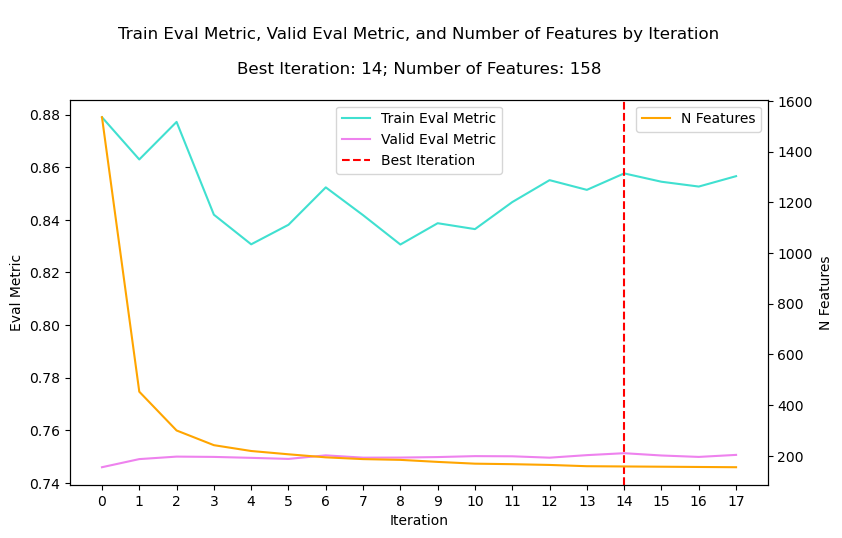

In [25]:
# plot
df.sort_values(by='iteration', ascending=True, inplace=True)
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Train Eval Metric, Valid Eval Metric, and Number of Features by Iteration\n
Best Iteration: {int_best_iteration}; Number of Features: {int_n_cols}
"""
ax.set_title(str_title)
ax.set_xlabel('Iteration')
ax.set_ylabel('Eval Metric')
ax.plot(df['iteration'].astype(str), df['flt_eval_metric_train'], label='Train Eval Metric', color='turquoise')
ax.plot(df['iteration'].astype(str), df['flt_eval_metric_valid'], label='Valid Eval Metric', color='violet')
ax.axvline(int_best_iteration, label='Best Iteration', color='red', linestyle='--')
plt.legend(loc='upper center')

ax2 = ax.twinx()
ax2.set_ylabel('N Features')
ax2.plot(df['iteration'].astype(str), df['n_feats'], color='orange', label='N Features')
plt.legend(loc='upper right')
plt.savefig(f'{str_dirname_output}/plt_feat_select_1.png', bbox_inches='tight')
plt.show()

In [26]:
# get the metrics we want to match up with
flt_eval_metric_train_2 = df['flt_eval_metric_train'].iloc[0]
flt_eval_metric_valid_2 = df['flt_eval_metric_valid'].iloc[0]
print(f'First Iteration of Feature Selection: Train score: {flt_eval_metric_train_2:0.5f}; Valid score: {flt_eval_metric_valid_2:0.5f}')

First Iteration of Feature Selection: Train score: 0.87902; Valid score: 0.74596


In [27]:
# make sure the first iteration of feature selection matches with best tuning job
if (flt_eval_metric_train_1 == flt_eval_metric_train_2) and (flt_eval_metric_valid_1 == flt_eval_metric_valid_2):
    print('Success, the first iteration of feature selection matches the best tuning job.')
else:
    print('Alert! The first iteration of feature selection does not match the best tuning job')

Success, the first iteration of feature selection matches the best tuning job.


In [28]:
# save more metrics for matching
flt_eval_metric_train_3 = df[df['n_feats']==int_n_cols]['flt_eval_metric_train'].iloc[0]
flt_eval_metric_valid_3 = df[df['n_feats']==int_n_cols]['flt_eval_metric_valid'].iloc[0]
print(f'Best List of Features from Feature Selection: Train score: {flt_eval_metric_train_3:0.5f}; Valid score: {flt_eval_metric_valid_3:0.5f}')

Best List of Features from Feature Selection: Train score: 0.85766; Valid score: 0.75129


## Model building

### Step function schematic

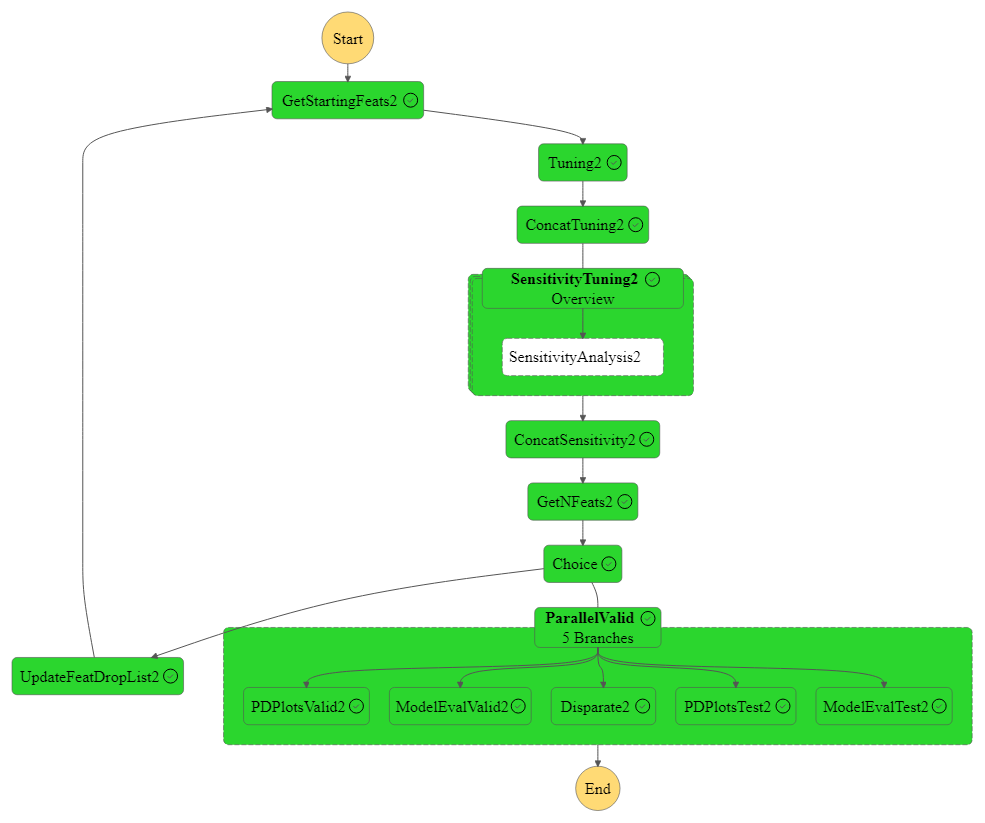

In [29]:
# download
str_filename = 'schematic.png'
str_local_path = f'../../02_model/12_step_function/img/{str_filename}'

# show
Image(filename=str_local_path)

### Hyperparameters for step function

In [30]:
str_filename = 'df_hyperparameters.csv'
str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/02_model/12_step_function/{str_filename}'
df = pd.read_csv(str_uri)
# show
df

,keys,values
0,STR_FILENAME_TRAIN,df_train_noleaks_pre.gzip
1,STR_FILENAME_VALID,df_valid_noleaks_pre.gzip
2,STR_FILENAME_TEST,df_test_noleaks_pre.gzip
3,INT_N_ITERATIONS,1000
4,PROP_EARLY_STOPPING,0.1
5,INT_N_TUNING_JOBS_2,50
6,STR_EVAL_METRIC,AUC


### Features to drop

In [31]:
str_filename = 'df_feats_to_drop.csv'
str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/02_model/01_lambda_get_starting_feats/{str_filename}'
list_feats_drop = list(pd.read_csv(str_uri)['feature'])
print(f'There is/are {len(list_feats_drop)} feature(s) to drop:')
pprint(list_feats_drop)

There is/are 0 feature(s) to drop:
[]


In [32]:
try:
    list_df = []
    for col in list_feats_drop:
        # import
        str_filename = f'df_output_{col}.csv'
        str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/02_model/04_batch_sensitivity_analysis/models/{str_filename}'
        df = pd.read_csv(str_uri)
        # append
        list_df.append(df)
    # create df
    df = pd.concat(list_df)

    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title('Train and Valid Eval Metric and Scaled Rating by Feature Dropped')
    ax.set_ylabel('Eval Metric')
    ax.plot(df['feature'], df['flt_eval_metric_train'], color='turquoise', label='Train Eval Metric')
    ax.plot(df['feature'], df['flt_eval_metric_valid'], color='violet', label='Valid Eval Metric')
    ax.set_xticklabels(list(df['feature']), rotation=90)
    plt.legend()
    # save
    plt.savefig(f'{str_dirname_output}/plt_dropped_features.png', bbox_inches='tight')
    plt.show()
except ValueError:
    pass

### Features in the model

In [33]:
str_filename = 'df_cols_in_model.csv'
str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/02_model/01_lambda_get_starting_feats/{str_filename}'
list_cols_model = list(pd.read_csv(str_uri)['feature'])
print(f'There are {len(list_cols_model)} features in the model:')
if len(list_cols_model) <= 100:
    pprint(list_cols_model)
else:
    pass

There are 158 features in the model:


### Tuning

In [34]:
str_filename = 'df_tuning.csv'
str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/02_model/03_lambda_concat_tuning/{str_filename}'
df = pd.read_csv(str_uri)
# show
df.head(10)

,iteration,learning_rate,flt_eval_metric_train,flt_eval_metric_valid,diff,best_iteration
0,5,0.0514,0.857665,0.751291,0.106374,998
1,6,0.0615,0.864579,0.750559,0.114020,956
2,8,0.0816,0.859763,0.750149,0.109613,686
3,4,0.0413,0.847234,0.750022,0.097212,999
4,10,0.1018,0.843935,0.749343,0.094592,399
5,3,0.0312,0.830315,0.749241,0.081073,994
6,11,0.1119,0.834122,0.749142,0.084980,321
7,7,0.0716,0.834963,0.749127,0.085836,482
8,12,0.1220,0.840768,0.749031,0.091737,310
9,13,0.1321,0.864246,0.748492,0.115755,459


In [35]:
df.tail(10)

,iteration,learning_rate,flt_eval_metric_train,flt_eval_metric_valid,diff,best_iteration
40,35,0.3538,0.843462,0.742400,0.101062,139
41,39,0.3942,0.804897,0.742024,0.062873,59
42,41,0.4143,0.823206,0.741565,0.081641,84
43,46,0.4647,0.811028,0.741474,0.069555,59
44,49,0.4950,0.808466,0.741032,0.067435,53
45,44,0.4446,0.828717,0.740947,0.087771,92
46,43,0.4345,0.795121,0.740752,0.054369,42
47,47,0.4748,0.820610,0.740707,0.079903,66
48,48,0.4849,0.795496,0.739472,0.056023,37
49,0,0.0010,0.742936,0.715354,0.027581,998


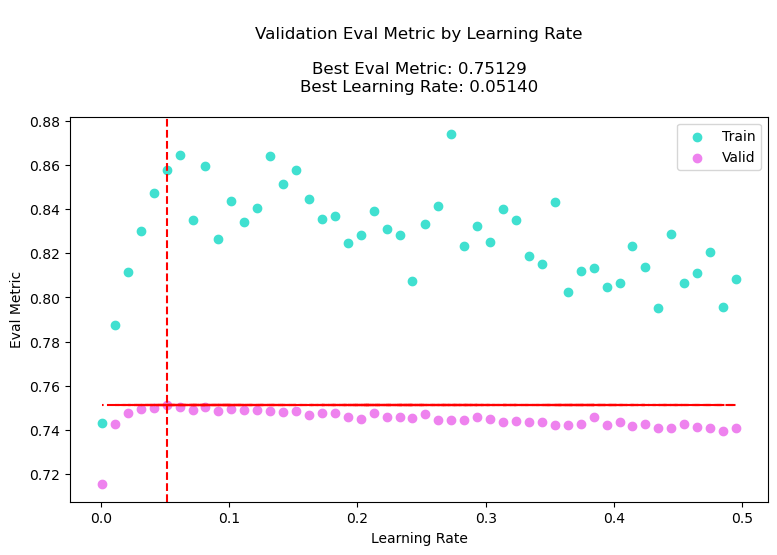

In [36]:
# plot
fig, ax = plt.subplots(figsize=(9,5))
flt_best_lr = df['learning_rate'].iloc[0]
flt_best_metric = df['flt_eval_metric_valid'].iloc[0]
str_title = f"""
Validation Eval Metric by Learning Rate

Best Eval Metric: {flt_best_metric:0.5f}
Best Learning Rate: {flt_best_lr:0.5f}
"""
ax.set_title(str_title)
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Eval Metric')
ax.scatter(df['learning_rate'], df['flt_eval_metric_train'], label='Train', color='turquoise')
ax.scatter(df['learning_rate'], df['flt_eval_metric_valid'], label='Valid', color='violet')
ax.axvline(x=flt_best_lr, linestyle='--', color='red')
ax.plot(df['learning_rate'], [flt_best_metric for a in range(df.shape[0])], linestyle='--', color='red')
plt.legend()
# save and show
plt.savefig(f'{str_dirname_output}/plt_tuning_2.png', bbox_inches='tight')
plt.show()

In [37]:
# get the metrics we want to match up with
flt_eval_metric_train_4 = df['flt_eval_metric_train'].iloc[0]
flt_eval_metric_valid_4 = df['flt_eval_metric_valid'].iloc[0]
print(f'Best Tuning Job 2: Train score: {flt_eval_metric_train_4:0.5f}; Valid score: {flt_eval_metric_valid_4:0.5f}')

Best Tuning Job 2: Train score: 0.85766; Valid score: 0.75129


In [38]:
# make sure the best tuning job 2 has a valid eval metric >= the best validation metric from feature selection
if flt_eval_metric_valid_4 >= flt_eval_metric_valid_3:
    print('Success, the best tuning job has validation performance at least as good as the best feature selection job.')
else:
    print('Alert! The best tuning job has validation performance worse than the best feature selection job.')

Success, the best tuning job has validation performance at least as good as the best feature selection job.


### Progress table

In [39]:
df = pd.DataFrame({
    'Step': ['Tuning 1 - Best Valid', 'Tuning 1 - Best', 'Feature Selection - First', 'Feature Selection - Best', 'Tuning 2 - Best'],
    'Train': [flt_eval_metric_train_0, flt_eval_metric_train_1, flt_eval_metric_train_2, flt_eval_metric_train_3, flt_eval_metric_train_4],
    'Valid': [flt_eval_metric_valid_0, flt_eval_metric_valid_1, flt_eval_metric_valid_2, flt_eval_metric_valid_3, flt_eval_metric_valid_4],
})
# show
df

,Step,Train,Valid
0,Tuning 1 - Best Valid,0.879020,0.745963
1,Tuning 1 - Best,0.879020,0.745963
2,Feature Selection - First,0.879020,0.745963
3,Feature Selection - Best,0.857665,0.751291
4,Tuning 2 - Best,0.857665,0.751291


/tmp/ipykernel_4947/2432065589.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(df['Step']), rotation=45)


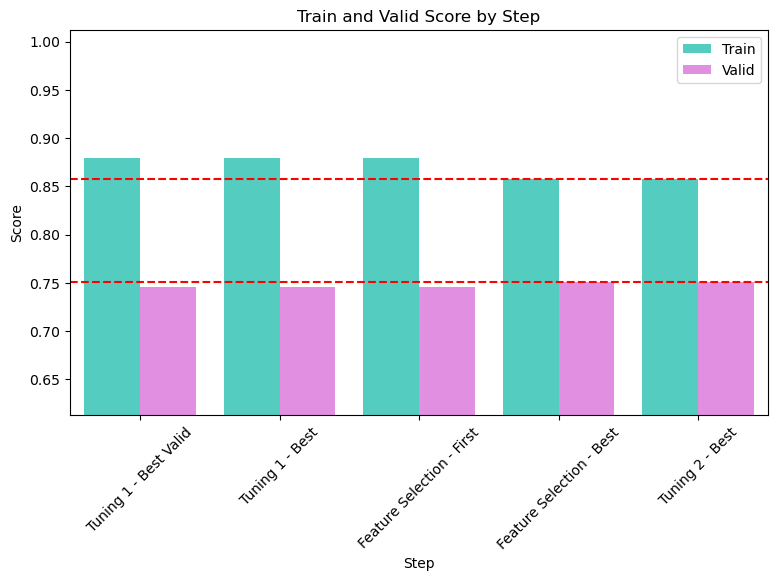

In [40]:
# make grouped bar plot
df_long = pd.melt(
    df,
    id_vars=['Step'],
    var_name='Data Set',
    value_name='Score',
)
# get ymin and max
flt_ymax = np.max(df_long['Score'])
flt_ymin = np.min(df_long['Score'])
flt_range = flt_ymax - flt_ymin
flt_ymin = flt_ymin - flt_range
flt_ymax = flt_ymax + flt_range

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Train and Valid Score by Step')
sns.barplot(data=df_long, x='Step', y='Score', hue='Data Set', ax=ax, palette=['turquoise','violet'])
# horizontal line - train
ax.axhline(df['Train'].iloc[-1], linestyle='--', color='red')
# horizontal line - valid
ax.axhline(df['Valid'].iloc[-1], linestyle='--', color='red')
ax.set_xticklabels(list(df['Step']), rotation=45)
ax.set_ylim(bottom=flt_ymin, top=flt_ymax)
plt.legend(loc='upper right')
# save and show
str_filename = 'plt_progress_table.png'
str_local_path =  f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')
plt.show()

### Hyperparameters

In [41]:
# download model
str_filename = 'final_model.pkl'
str_local_path = f'./{str_filename}'
str_bucket_path = f'{str_model}/02_model/{str_variant}/03_final_model/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
# show pipeline
cls_model_inference = pickle.load(open(str_local_path, 'rb'))['model_inference']
print('')
print('Hyperparameters:')
pprint(cls_model_inference.get_params())

# rm
os.remove(str_local_path)


Hyperparameters:
{'eval_metric': 'AUC',
 'iterations': 1000,
 'learning_rate': 0.0514,
 'monotone_constraints': {'ENG-loan_to_value': 1,
                          'fltadvance__app': 1,
                          'fltapproveddowntotal__app': -1,
                          'fltdowncash__app': -1,
                          'fltgrossmonthly__income_count': 1,
                          'fltgrossmonthly__income_sum': -1,
                          'pti__app': 1},
 'nan_mode': 'Min',
 'random_state': 42,
 'task_type': 'CPU'}


### Sensitivity analysis

In [42]:
# feat importance (via sensitivity analysis)
list_cols = [
    'feature',
    'flt_eval_metric_train',
    'flt_eval_metric_valid',
    'flt_score_to_beat',
    'performance',
    'helped',
]
str_filename = 'df_sensitivity.csv'
str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/02_model/05_lambda_concat_sensitivity/{str_filename}'
df = pd.read_csv(str_uri, usecols=list_cols)
df.sort_values(by='performance', ascending=True, inplace=True)

# get description
list_cols = [
    'feature',
    'description',
]
str_filename_tmp = 'df_descriptions.csv'
str_local_path = f'../../../../ad_hoc/get_descriptions_all/output/{str_variant}/{str_filename_tmp}'
df_descriptions = pd.read_csv(str_local_path, usecols=list_cols)

# join
df = pd.merge(
    left=df,
    right=df_descriptions,
    on='feature',
    how='left',
)

# save
str_local_path = f'{str_dirname_output}/{str_filename}'
df.to_csv(str_local_path, index=False)

int_n_feats = 10
print(f'{int_n_feats} most important features:')
df.head(int_n_feats)

10 most important features:


,feature,flt_eval_metric_train,flt_eval_metric_valid,flt_score_to_beat,performance,helped,description
0,fltgrossmonthly__income_sum,0.834427,0.741168,0.751291,-0.010123,0,Total income
1,intopenbktype__app,0.841208,0.745218,0.751291,-0.006073,0,BK Type
2,addrinputmatchindex__ln,0.823175,0.747552,0.751291,-0.003739,0,Index indicating if the input address matches ...
3,bankruptcystatus__ln,0.832633,0.747632,0.751291,-0.003659,0,Indicates status of most recent bankruptcy fil...
4,pti__app,0.853332,0.748740,0.751291,-0.002551,0,Payment to income
5,addrstabilityindex__ln,0.834546,0.748817,0.751291,-0.002474,0,Address stability index indicating how often s...
6,g230s__tu,0.846311,0.748924,0.751291,-0.002367,0,Number of 60 or more days past due trades (cur...
7,lm15s__tu,0.834277,0.748924,0.751291,-0.002367,0,Total balance of mortgage trades with a govern...
8,bankruptcycount24month__ln,0.857283,0.749147,0.751291,-0.002144,0,Total unique bankruptcy case filings on file s...
9,au20s__tu,0.843146,0.749158,0.751291,-0.002133,0,Months since oldest auto trade opened


In [43]:
# least important features
df.sort_values(by='performance', ascending=False, inplace=True)
print(f'{int_n_feats} least important features:')
df.head(int_n_feats)

10 least important features:


,feature,flt_eval_metric_train,flt_eval_metric_valid,flt_score_to_beat,performance,helped,description
157,std223__tu,0.844723,0.751195,0.751291,-0.000096,0,Average total Payment Ratio for Student Loan a...
156,evictioncount12month__ln,0.855273,0.751172,0.751291,-0.000119,0,Total eviction records on subject's file in th...
155,bankruptcytimenewest__ln,0.857756,0.751151,0.751291,-0.000140,0,Time (in months) since most recent bankruptcy ...
154,fltadvance__app,0.851728,0.751112,0.751291,-0.000178,0,Advance
153,std205__tu,0.856427,0.750894,0.751291,-0.000397,0,Total Payment Ratio for Student Loan accounts ...
152,s004s__tu,0.858383,0.750867,0.751291,-0.000423,0,Average number of months trades have been on file
151,s068b__tu,0.855243,0.750862,0.751291,-0.000429,0,Number of non-medical third party collections
150,criminalnonfelonycount__ln,0.857199,0.750860,0.751291,-0.000431,0,Total non-felony criminal convictions or sexua...
149,addrinputsubjectcount__ln,0.853475,0.750859,0.751291,-0.000432,0,Total number of unique subjects on file curren...
148,bitdealerapplicantsamezip__app,0.846867,0.750852,0.751291,-0.000439,0,Applicant and Dealer Same Zip


In [44]:
# get number of features that helped the model once they were removed
int_sum_helped = np.sum(df['helped'])
print(f'There were/was {int_sum_helped} feature(s) that helped model performance...')
if int_sum_helped > 0:
    print('Consider removing feature(s) that helped model and re-evaluate')
else:
    print('All features compromised model performance upon removal.')

There were/was 0 feature(s) that helped model performance...
All features compromised model performance upon removal.


/tmp/ipykernel_4947/3261082257.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_tmp['feature'], rotation=90)


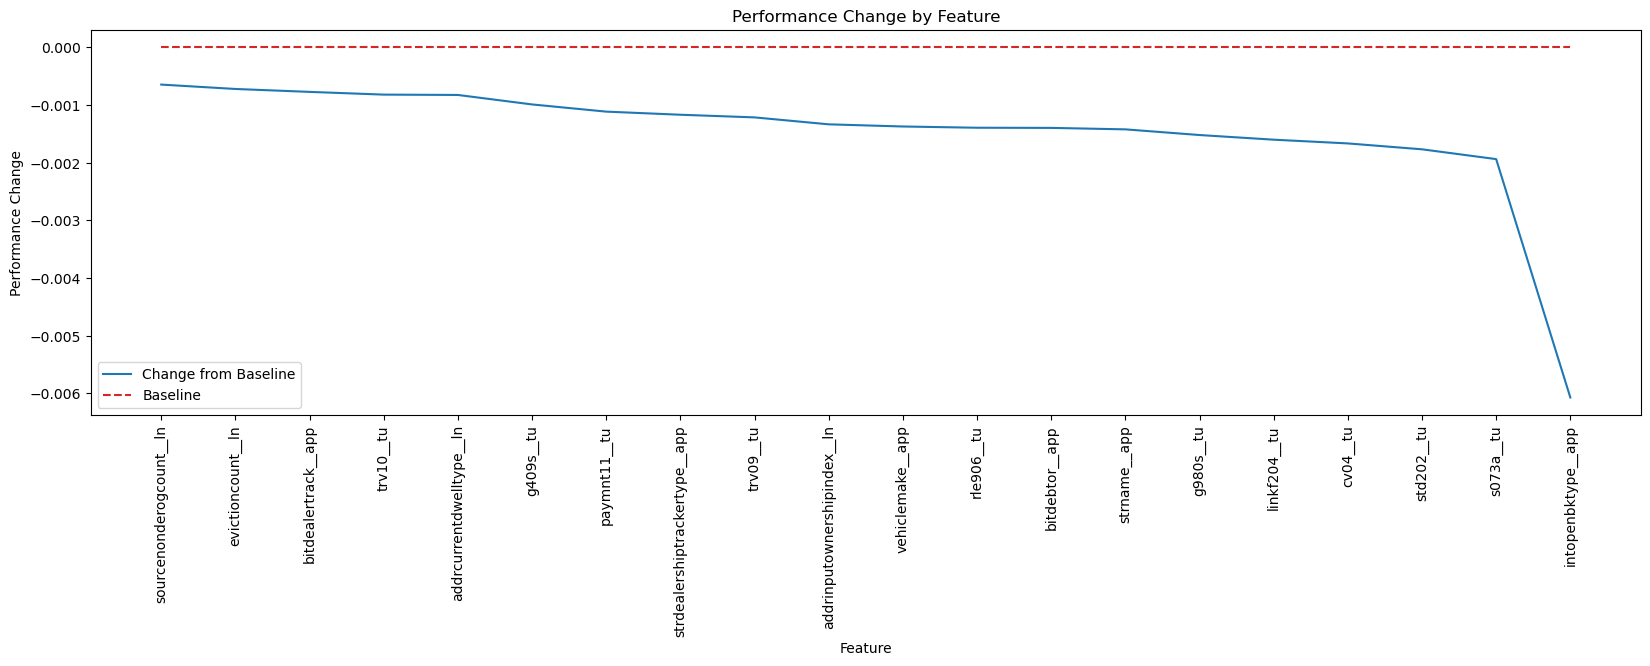

In [45]:
# take random sample to make plotting clearer
try:
    df_tmp = df.sample(n=20, random_state=42)
except ValueError:
    df_tmp = df.sample(n=df.shape[0], random_state=42)
df_tmp.sort_values(by='performance', ascending=False, inplace=True)

# plot
fig, ax = plt.subplots(figsize=(df_tmp.shape[0], 5))
ax.set_title('Performance Change by Feature')
ax.set_xlabel('Feature')
ax.set_ylabel('Performance Change')
ax.plot(df_tmp['feature'], df_tmp['performance'], label='Change from Baseline')
ax.plot(df_tmp['feature'], [0]*df_tmp.shape[0], linestyle='--', color='tab:red', label='Baseline')
ax.set_xticklabels(df_tmp['feature'], rotation=90)
plt.legend()
plt.savefig(f'{str_dirname_output}/plt_sensitivity_2.png', bbox_inches='tight')
plt.show()

### Disparate Impact - Valid

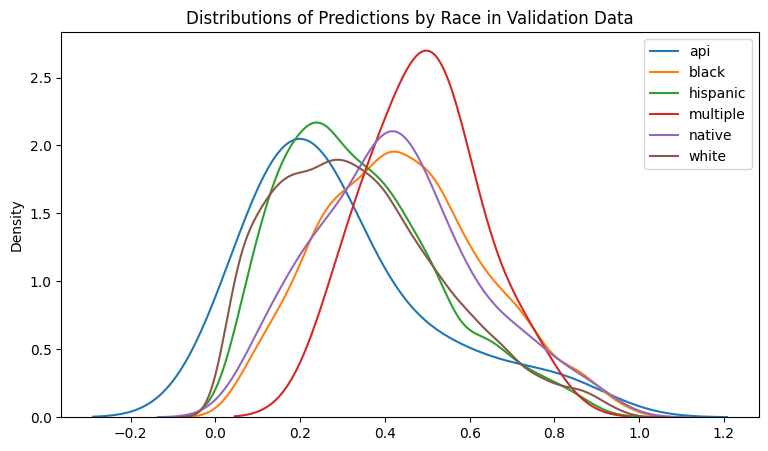

In [46]:
# race
str_filename = 'plt_yhat_dist_race.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=f'{str_model}/02_model/{str_variant}/02_model/11b_disparate_impact/{str_filename}', 
    str_project=str_project,
)
# show
Image(filename=str_local_path)

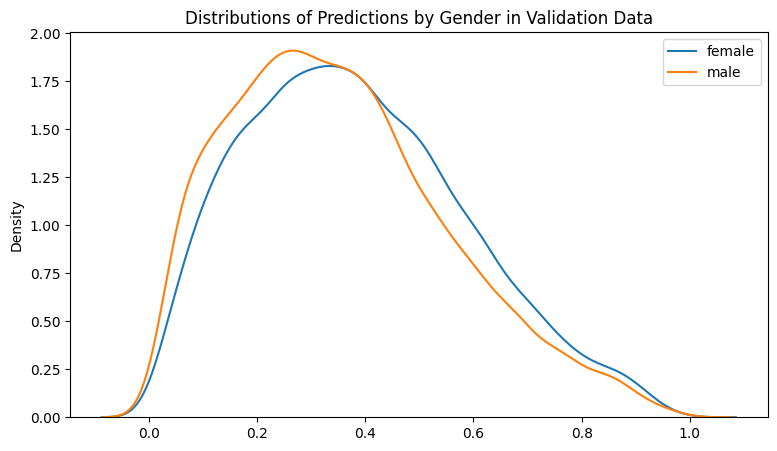

In [47]:
# gender
str_filename = 'plt_yhat_dist_gender.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=f'{str_model}/02_model/{str_variant}/02_model/11b_disparate_impact/{str_filename}', 
    str_project=str_project,
)
# show
Image(filename=str_local_path)

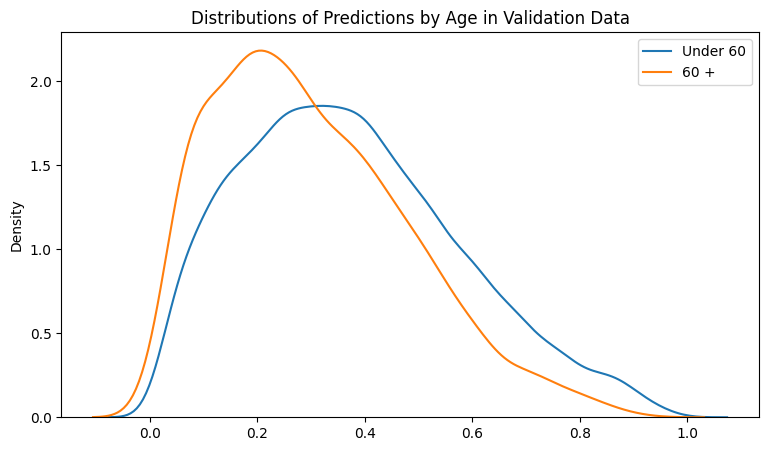

In [48]:
# age
str_filename = 'plt_yhat_dist_age.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=f'{str_model}/02_model/{str_variant}/02_model/11b_disparate_impact/{str_filename}',
    str_project=str_project,
)
# show
Image(filename=str_local_path)

In [49]:
# top features
list_str_filename = [
    'df_feat_imp_race.csv',
    'df_feat_imp_gender.csv',
    'df_feat_imp_age.csv',
]
list_list_features = []
for str_filename in list_str_filename:
    str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/02_model/11b_disparate_impact/{str_filename}'
    list_features = list(pd.read_csv(str_uri)['feature'])[:10]
    list_list_features.append(list_features)
# flatten list
list_features = [item for sublist in list_list_features for item in sublist]
# rm dups
list_features = list(dict.fromkeys(list_features))

# tag
df['disparate_feature'] = df['feature'].apply(lambda x: 1 if x in list_features else 0)
# subset
df = df[df['disparate_feature'] == 1]
# sort
df.sort_values(by='performance', ascending=True, inplace=True)

# save
str_filename = 'df_disparate.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df.to_csv(str_uri, index=False)

# show
df

,feature,flt_eval_metric_train,flt_eval_metric_valid,flt_score_to_beat,performance,helped,description,disparate_feature
0,fltgrossmonthly__income_sum,0.834427,0.741168,0.751291,-0.010123,0,Total income,1
4,pti__app,0.853332,0.748740,0.751291,-0.002551,0,Payment to income,1
5,addrstabilityindex__ln,0.834546,0.748817,0.751291,-0.002474,0,Address stability index indicating how often s...,1
23,std202__tu,0.843301,0.749524,0.751291,-0.001767,0,Total Payment Ratio for Student Loan accounts ...,1
25,st01s__tu,0.838886,0.749568,0.751291,-0.001722,0,Number of student loan trades,1
32,in25s__tu,0.848353,0.749675,0.751291,-0.001616,0,Number of currently open and satisfactory inst...,1
37,au01s__tu,0.852899,0.749702,0.751291,-0.001589,0,Number of auto trades,1
39,g106s__tu,0.848644,0.749725,0.751291,-0.001566,0,Months on file,1
42,jt20s__tu,0.830449,0.749742,0.751291,-0.001549,0,Months since oldest joint trade opened,1
49,dealerstate__app,0.832166,0.749806,0.751291,-0.001485,0,Dealer State,1


/tmp/ipykernel_4947/308851004.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['feature'], rotation=90)


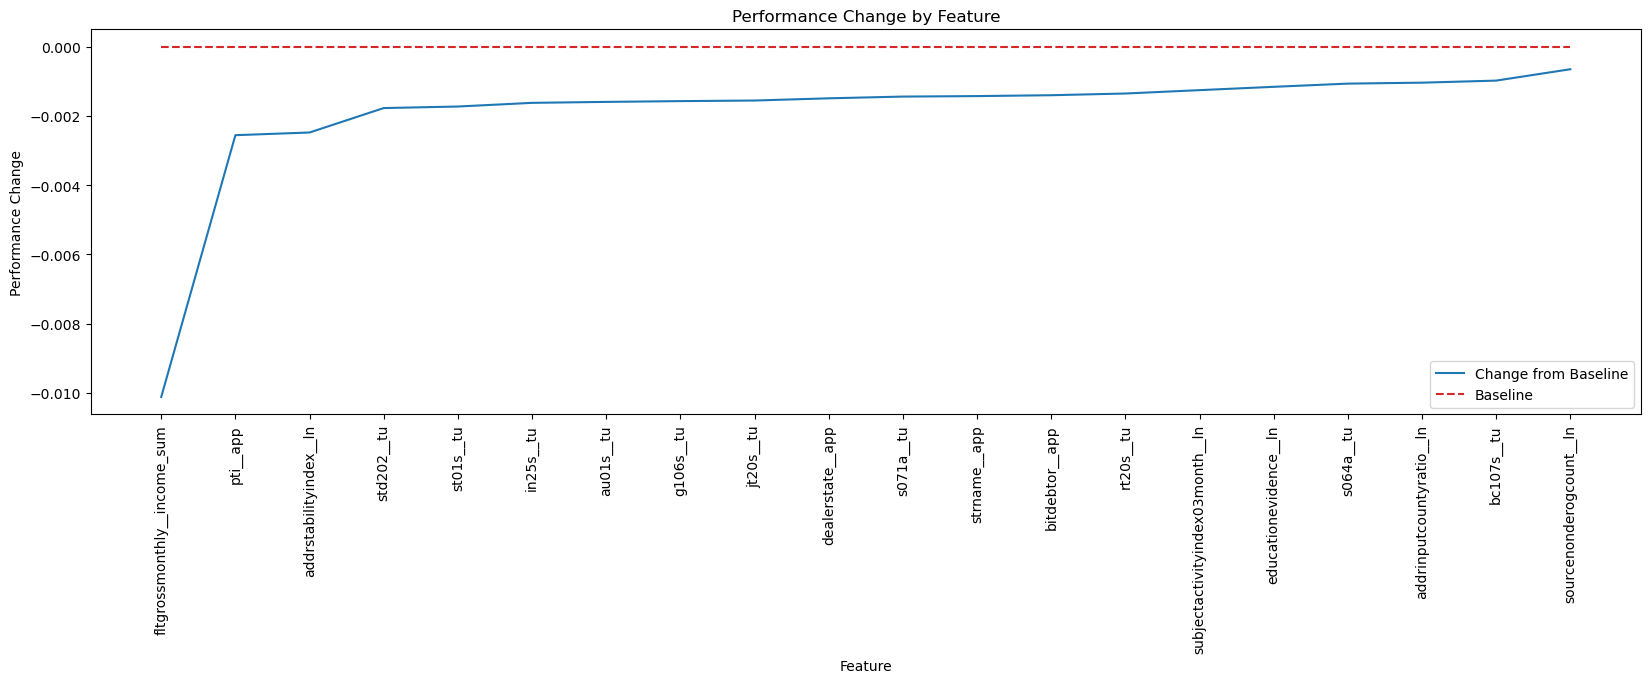

In [50]:
# plot
fig, ax = plt.subplots(figsize=(df.shape[0], 5))
ax.set_title('Performance Change by Feature')
ax.set_xlabel('Feature')
ax.set_ylabel('Performance Change')
ax.plot(df['feature'], df['performance'], label='Change from Baseline')
ax.plot(df['feature'], [0]*df.shape[0], linestyle='--', color='tab:red', label='Baseline')
ax.set_xticklabels(df['feature'], rotation=90)
plt.legend()
plt.savefig(f'{str_dirname_output}/plt_disparate.png', bbox_inches='tight')
plt.show()

### PD Plots - Valid

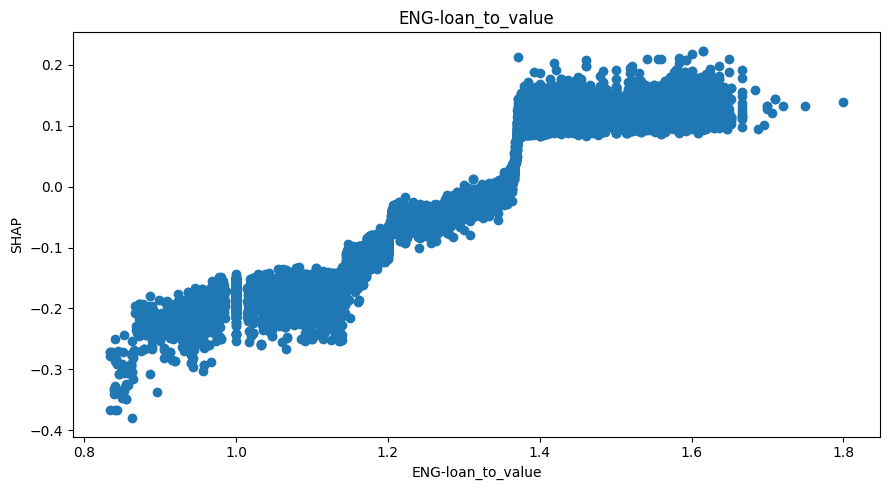

In [51]:
# get the most recently uploaded file
str_prefix = f'{str_model}/02_model/{str_variant}/02_model/08_batch_pd_plots_valid/plots'
cls_s3 = boto3.resource('s3')
# initialize bucket
cls_bucket = cls_s3.Bucket(str_project)
# use the bucket objects method to get a list of all objects in the bucket with the specified prefix
objects = cls_bucket.objects.filter(Prefix=str_prefix)
# sort the objects by last modified time
list_sorted_objects = sorted(objects, key=lambda x: x.last_modified, reverse=False)
# get the keys
list_sorted_objects = [obj.key for obj in list_sorted_objects]
# make sure gzip
list_sorted_objects = [str_key for str_key in list_sorted_objects if '.png' in str_key]
# get the key (i.e. filename) of the most recently modified object
str_filename = list_sorted_objects[0].split('/')[-1]

# download
str_local_path = f'{str_dirname_output}/{str_filename}'
str_bucket_path = f'{str_prefix}/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)

# show
Image(filename=str_local_path)

### Model eval - Valid

In [52]:
# download
str_filename = 'dict_eval_metrics_train.json'
str_local_path = f'{str_dirname_output}/{str_filename}'
str_bucket_path = f'{str_model}/02_model/{str_variant}/02_model/09_batch_model_eval_valid/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
# open
with open(str_local_path, 'r') as f:
    # Load the contents of the file as a Python object
    dict_metrics_train = json.load(f)

# make df
ser_metrics_train = pd.Series(dict_metrics_train)
df_metrics_train = pd.DataFrame({'train': ser_metrics_train})

# download
str_filename = 'dict_eval_metrics_valid.json'
str_local_path = f'{str_dirname_output}/{str_filename}'
str_bucket_path = f'{str_model}/02_model/{str_variant}/02_model/09_batch_model_eval_valid/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
# open
with open(str_local_path, 'r') as f:
    # Load the contents of the file as a Python object
    dict_metrics_valid = json.load(f)

# make df
ser_metrics_valid = pd.Series(dict_metrics_valid)
df_metrics_valid = pd.DataFrame({'valid': ser_metrics_valid})

# join
df_metrics = df_metrics_train.join(df_metrics_valid)

# save
str_filename = 'df_valid_model_eval_metrics.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_metrics.to_csv(str_local_path, index=False)

# show
df_metrics

,train,valid
accuracy,0.756492,0.675743
precision,0.618298,0.551936
recall,0.812166,0.695915
f1,0.702095,0.615619
roc_auc,0.857665,0.751291
pr_auc,0.781152,0.642126
log_loss,0.462411,0.561201


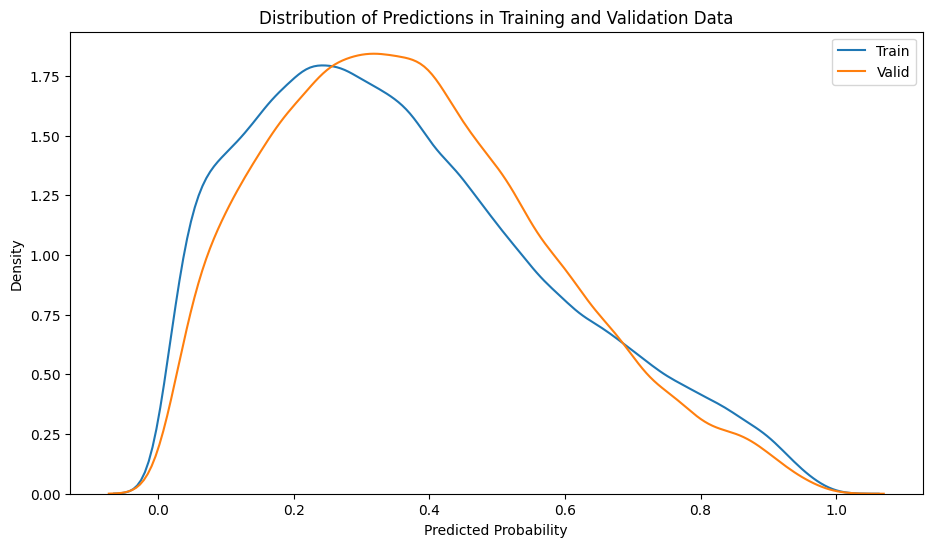

In [53]:
# download
str_filename = 'plt_dist_yhat.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
str_bucket_path = f'{str_model}/02_model/{str_variant}/02_model/09_batch_model_eval_valid/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)

# show
Image(filename=str_local_path)

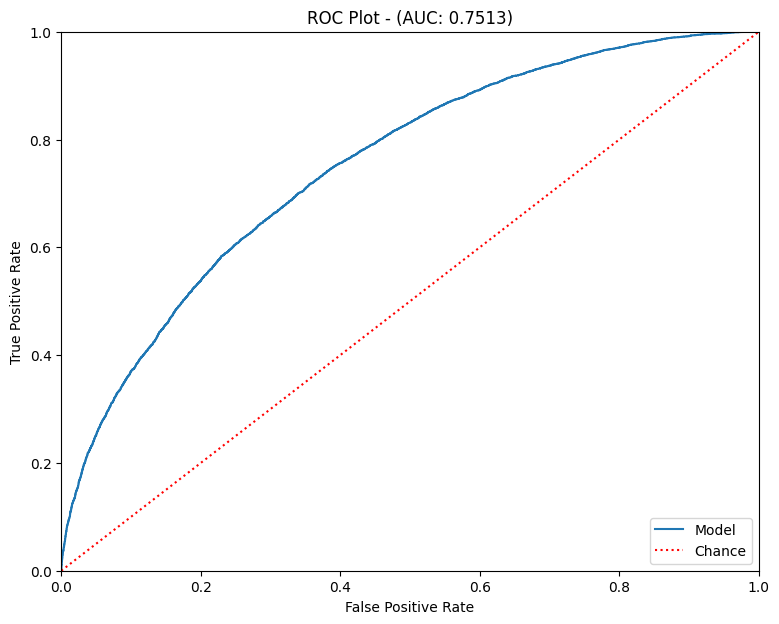

In [54]:
# download
str_filename = 'plt_roc_auc_valid.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
str_bucket_path = f'{str_model}/02_model/{str_variant}/02_model/09_batch_model_eval_valid/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)

# show
Image(filename=str_local_path)

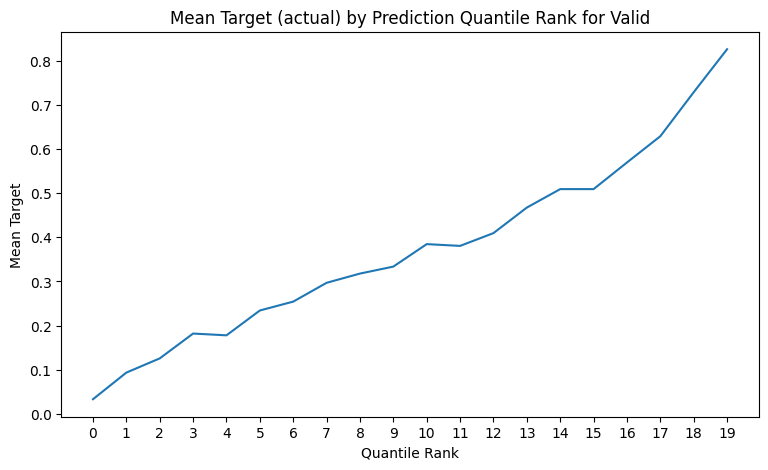

In [55]:
# download
str_filename = 'plt_lift_valid.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
str_bucket_path = f'{str_model}/02_model/{str_variant}/02_model/09_batch_model_eval_valid/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)

# show
Image(filename=str_local_path)

### PD plots - Test

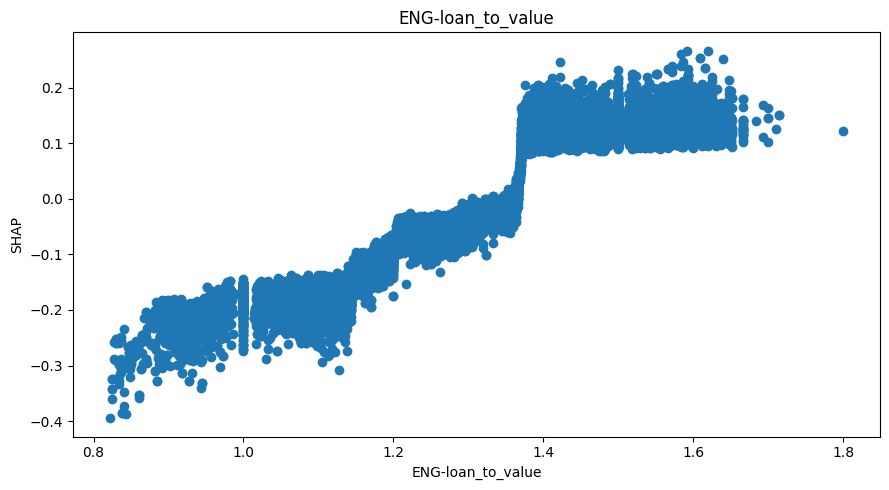

In [56]:
# get the most recently uploaded file
str_prefix = f'{str_model}/02_model/{str_variant}/02_model/10_batch_pd_plots_test/plots'
cls_s3 = boto3.resource('s3')
# initialize bucket
cls_bucket = cls_s3.Bucket(str_project)
# use the bucket objects method to get a list of all objects in the bucket with the specified prefix
objects = cls_bucket.objects.filter(Prefix=str_prefix)
# sort the objects by last modified time
list_sorted_objects = sorted(objects, key=lambda x: x.last_modified, reverse=False)
# get the keys
list_sorted_objects = [obj.key for obj in list_sorted_objects]
# make sure gzip
list_sorted_objects = [str_key for str_key in list_sorted_objects if '.png' in str_key]
# get the key (i.e. filename) of the most recently modified object
str_filename = list_sorted_objects[0].split('/')[-1]

# download
str_local_path = f'{str_dirname_output}/{str_filename}'
str_bucket_path = f'{str_prefix}/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)

# show
Image(filename=str_local_path)

### Model eval - Test

In [57]:
# download
str_filename = 'dict_eval_metrics_train.json'
str_local_path = f'{str_dirname_output}/{str_filename}'
str_bucket_path = f'{str_model}/02_model/{str_variant}/02_model/11_batch_model_eval_test/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
# open
with open(str_local_path, 'r') as f:
    # Load the contents of the file as a Python object
    dict_metrics_train = json.load(f)

# make df
ser_metrics_train = pd.Series(dict_metrics_train)
df_metrics_train = pd.DataFrame({'train': ser_metrics_train})

# download
str_filename = 'dict_eval_metrics_test.json'
str_local_path = f'{str_dirname_output}/{str_filename}'
str_bucket_path = f'{str_model}/02_model/{str_variant}/02_model/11_batch_model_eval_test/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
# open
with open(str_local_path, 'r') as f:
    # Load the contents of the file as a Python object
    dict_metrics_test = json.load(f)

# make df
ser_metrics_test = pd.Series(dict_metrics_test)
df_metrics_test = pd.DataFrame({'test': ser_metrics_test})

# join
df_metrics = df_metrics_train.join(df_metrics_test)

# save
str_filename = 'df_test_model_eval_metrics.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_metrics.to_csv(str_local_path, index=False)

# show
df_metrics

,train,test
accuracy,0.756492,0.580397
precision,0.618298,0.392876
recall,0.812166,0.802535
f1,0.702095,0.527512
roc_auc,0.857665,0.714699
pr_auc,0.781152,0.502422
log_loss,0.462411,0.554729


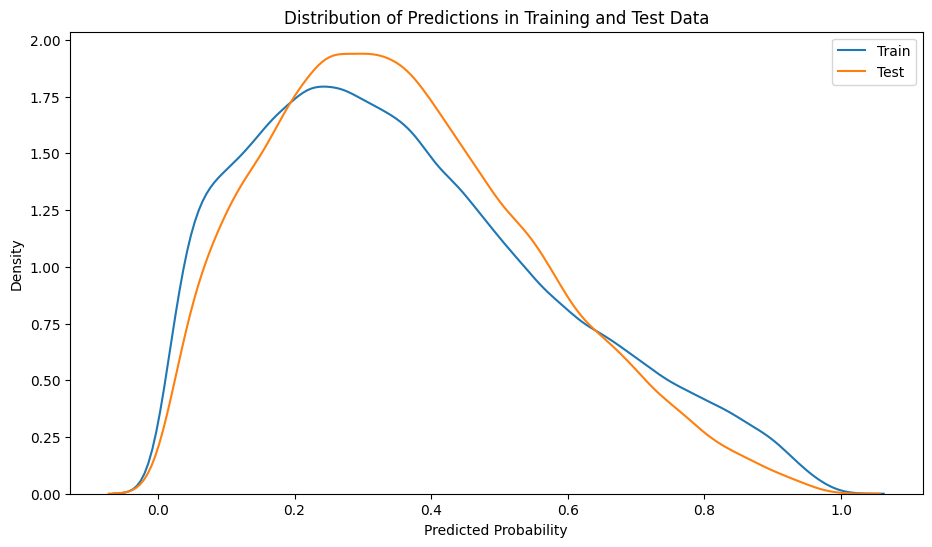

In [58]:
# download
str_filename = 'plt_dist_yhat.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
str_bucket_path = f'{str_model}/02_model/{str_variant}/02_model/11_batch_model_eval_test/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)

# show
Image(filename=str_local_path)

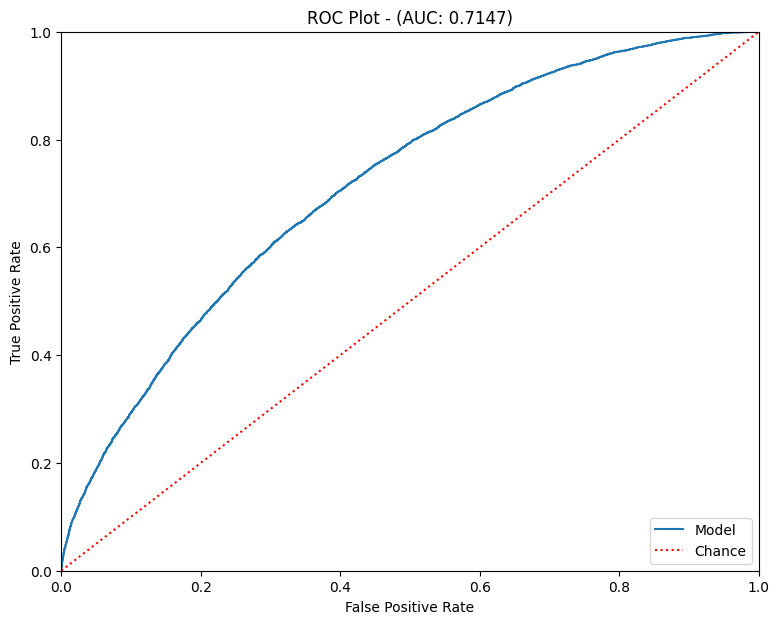

In [59]:
# download
str_filename = 'plt_roc_auc_test.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
str_bucket_path = f'{str_model}/02_model/{str_variant}/02_model/11_batch_model_eval_test/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)

# show
Image(filename=str_local_path)

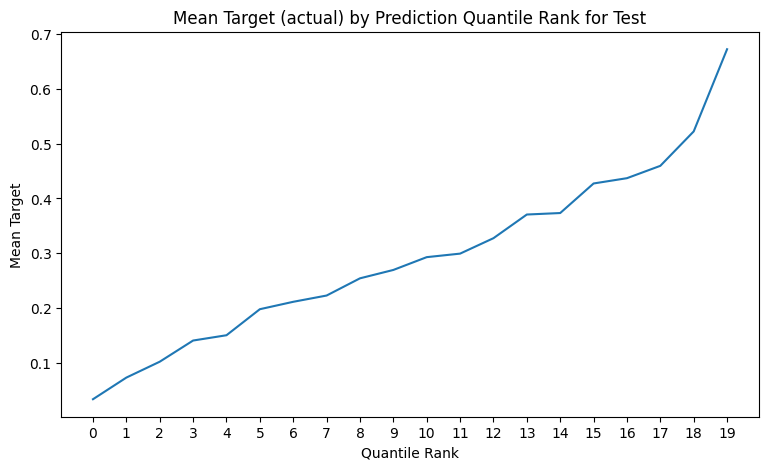

In [60]:
# download
str_filename = 'plt_lift_test.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
str_bucket_path = f'{str_model}/02_model/{str_variant}/02_model/11_batch_model_eval_test/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)

# show
Image(filename=str_local_path)